In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import cv2
from keras.layers import Flatten, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from keras.applications.vgg16 import VGG16
from keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications import MobileNetV3Large

In [2]:
mask_data_train = 'Face Mask Dataset/Train'
mask_data_test = 'Face Mask Dataset/Test'
val_data_train = 'Face Mask Dataset/Validation'

In [3]:
img_width = 150
img_height = 150

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(mask_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 20815 files belonging to 2 classes.


In [5]:
data_test = tf.keras.utils.image_dataset_from_directory(mask_data_test,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 992 files belonging to 2 classes.


In [6]:
val_train = tf.keras.utils.image_dataset_from_directory(val_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 800 files belonging to 2 classes.


In [7]:
data_cat = data_train.class_names
data_cat

['WithMask', 'WithoutMask']

In [8]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

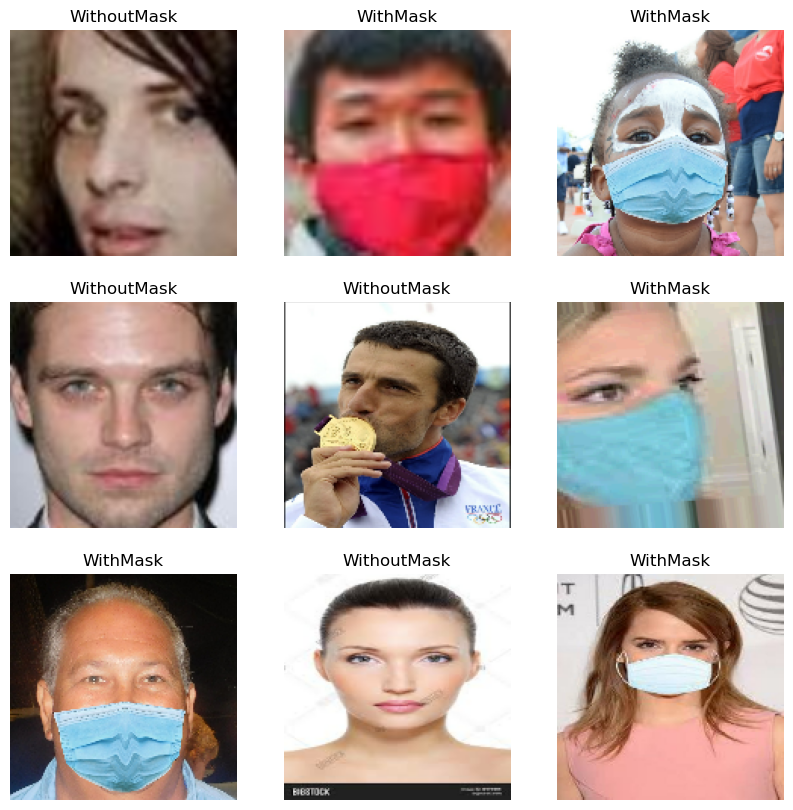

In [9]:
plt.figure(figsize=(10, 10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
CN_bas = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

C:\Users\krish dayani\AppData\Local\Temp\ipykernel_18852\1920435708.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  CN_bas = MobileNetV2(


In [11]:
CN_bas.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [12]:
CN_bas.trainable = False

In [13]:
model = Sequential()
model.add(CN_bas)
model.add(GlobalAveragePooling2D())
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
def process(image, label):
    image = tf.cast(image/255. , tf.float32)
    return image, label
data_train = data_train.map(process)
val_train = val_train.map(process)

In [16]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
            loss = keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [17]:
epochs = 10
history = model.fit(data_train,validation_data=val_train, epochs = epochs)

Epoch 1/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 209s 313ms/step - accuracy: 0.9678 - loss: 0.4703 - val_accuracy: 0.9962 - val_loss: 0.3584
Epoch 2/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 212s 326ms/step - accuracy: 0.9841 - loss: 0.3593 - val_accuracy: 0.9987 - val_loss: 0.2955
Epoch 3/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 247s 378ms/step - accuracy: 0.9872 - loss: 0.2995 - val_accuracy: 0.9987 - val_loss: 0.2461
Epoch 4/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 248s 380ms/step - accuracy: 0.9898 - loss: 0.2488 - val_accuracy: 0.9975 - val_loss: 0.2066
Epoch 5/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 250s 383ms/step - accuracy: 0.9926 - loss: 0.2070 - val_accuracy: 0.9987 - val_loss: 0.1717
Epoch 6/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 251s 385ms/step - accuracy: 0.9936 - loss: 0.1728 - val_accuracy: 0.9987 - val_loss: 0.1433
Epoch 7/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 252s 386ms/step - accuracy: 0.9940 - loss: 0.1446 - val_accuracy: 0.9987 - val_loss: 0.1192
Epoch 8/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 217s 333ms/step - accuracy: 0.9943 -

In [18]:
epoch_range = range(epochs)
plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [102]:
image = '1.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_width, img_height))
img_arr = tf.keras.utils.img_to_array(image)
img_arr = img_arr/255.0
img_bat = tf.expand_dims(img_arr, 0)

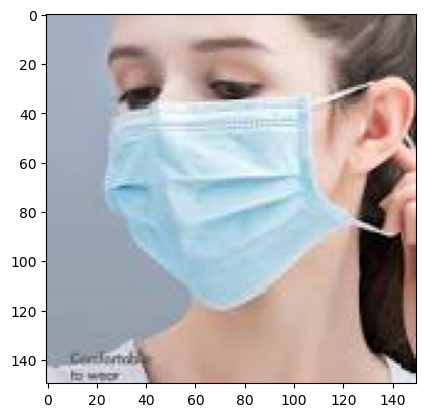

In [103]:
plt.imshow(image)

In [123]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [124]:
predict

array([[0.00012011]], dtype=float32)

In [125]:
cap = cv2.VideoCapture(0)

In [126]:
def detect_face_mask(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, (150,150))
    face = face.astype("float32") / 255.0
    face = np.expand_dims(face, axis=0)
    prediction = model.predict(face, verbose=0)[0][0]
    return prediction

In [127]:
def draw_label(img, text, pos, bg_color):
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, cv2.FILLED)
    end_x = pos[0] + text_size[0][0] + 2
    end_y = pos[1] + text_size[0][1] - 2
    cv2.rectangle(img, pos, (end_x, end_y), bg_color, cv2.FILLED)
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1, cv2.LINE_AA)

In [128]:
haar = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [129]:
def detect_face(img):
    cood = haar.detectMultiScale(img)
    return cood

In [131]:
while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = haar.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        pred = detect_face_mask(face)
        if pred > 0.5:
            label = "No Mask"
            color = (0,0,255)
        else:
            label = "Mask"
            color = (0,255,0)
        cv2.rectangle(frame, (x,y), (x+w,y+h), color, 2)
        draw_label(frame, label, (x,y-10), color)
    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord('x'):
        break
cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
